In [5]:
import torch
import torch.nn as nn
from torchvision import models
from torchvision import transforms
from social_media_overlay.ext.gebhardt.models.utilities.MeanReplicatedCrops import MeanReplicatedCrops
from social_media_overlay.ext.gebhardt.models.utilities.ReplicateAndCrop import ReplicateAndCrop
from social_media_overlay.ext.gebhardt.dataset.CocoCaptions import CocoCaptions
import matplotlib.pyplot as plt
import sys

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
path_to_model = "../data/gebhardt/models/va_pred_all"

weight = 1 # factor with which the calculated loss is multiplied
is_minimized = True # flag which indicates if loss is minimized or maximized (default=True)
loss = "va" # specifies type of loss (default = 'va'). Options are 'va', 'valence', 'arousal'.
is_input_range_0_1 = False # : flag that specifies if input range of images is 0 to 1 (default = True). If False, input range is assumed to be -1 to 1.
normalize = is_input_range_0_1
input_size = 480 # Size images of the dataset get resized to
crop_size = 448 # Size of center crop performed with images
requires_grad = True # if true model parameters are set to require a gradient
num_classes = 4 # why 4; number of neurons in output layer
activation_function = torch.nn.Sigmoid() # Activation function to use on model outputs
is_ten_crop=True # if true each image in batch gets replicated ten times and cropped randomly
# the prediction is then averaged...

# Model loading ------------------------------------------------------------------------------------
modelresnet50 = models.resnet50()
num_ft = modelresnet50.fc.in_features
modelresnet50.fc = nn.Linear(num_ft, num_classes)
modelresnet50.load_state_dict(torch.load(path_to_model))
if not requires_grad:
    if hasattr(modelresnet50, 'parameters'):
        for p in modelresnet50.parameters():
            p.requires_grad = False
modelresnet50.eval()
print()
modules = []
num_replications = 10
if input_size is not None:
    modules.append(transforms.Resize(input_size, antialias=True))
if crop_size is not None:
    if not is_ten_crop:
        modules.append(transforms.CenterCrop(crop_size))
    else:
        modules.append(ReplicateAndCrop(crop_size, normalize, num_replications))
if normalize and not is_ten_crop:
    modules.append(transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)))

modules.append(modelresnet50)

if is_ten_crop:
    modules.append(MeanReplicatedCrops(num_replications))

if activation_function is not None:
    modules.append(activation_function)

model = nn.Sequential(*modules)

# --------------------------------------------------------------
model.to(device)


# Define Error
def get_valence_error(predicted, target):
    if target is None:
        if is_minimized:
            # low valence:
            # sets the target for predictions over 0.5 to 0 and for under 0.5 to 1
            # target = (predicted < 0.5).int() * torch.ones(predicted.size(0)).to(self.device)
            target = 0.5 * torch.ones(predicted.size(0)).to(device)
            # target = torch.zeros(predicted.size(0)).to(device)
        else:
            # high valence:
            target = torch.ones(predicted.size(0)).to(device)

    error = target - predicted
    return error * error


def get_arousal_error(predicted, target):
    if target is None:
        if is_minimized:
            # low arousal:
            target = torch.zeros(predicted.size(0)).to(device)
        else:
            # high arousal:
            target = torch.ones(predicted.size(0)).to(device)

    error = target - predicted
    return error * error


def get_valence_arousal_error(predicted, target):
    if target is not None:
        val_error = get_valence_error(predicted[:, 0], target[:, 0])
        ar_error = get_arousal_error(predicted[:, 1], target[:, 1])
    else:
        val_error = get_valence_error(predicted[:, 0], None)
        ar_error = get_arousal_error(predicted[:, 1], None)
    return val_error + ar_error


if loss == "valence":
    get_error = get_valence_error
    output_ixs = [0]  # access valence mean 0, arousal mean 1, valence std 2 and arousal std 3
elif loss == "arousal":
    get_error = get_arousal_error
    output_ixs = [1]
else:
    get_error = get_valence_arousal_error
    output_ixs = [0, 1]


def predict(imgs: torch.Tensor) -> torch.Tensor:
    with torch.no_grad():
        imgs = imgs.to(device, non_blocking=True)
        return model(imgs)[:, output_ixs]

In [6]:
transform_input_size = 1024
transform_crop_size = 1024
print(sys.version)

size = 1024
batch_size = 1

data_transforms = transforms.Compose([
    transforms.Resize(transform_input_size),
    transforms.CenterCrop(transform_crop_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])
dataset_test = CocoCaptions("../data/coco", "val", data_transforms)
data_loader = torch.utils.data.DataLoader(dataset_test, batch_size=batch_size, shuffle=False, num_workers=0)

3.10.12 (main, Jun 11 2023, 05:26:28) [GCC 11.4.0]
COCO Dataset Debug Info
Root: ../data/coco
Split: val
Annotation file: ../data/coco/annotations/captions_val2017.json
Image directory: ../data/coco/val2017
Root exists ✓
Annotation file exists ✓
Image directory exists ✓
Images found in directory: 5000
Loading annotation metadata...
Entries in image_list: 5000
Dataset initialization finished.


In [14]:
predictions = []
for i, (imgs, _) in enumerate(data_loader):
    if i >= 30:
        break

    imgs = imgs.to(device)
    preds = predict(imgs)
    predictions.append(preds.detach().cpu())

predictions = torch.cat(predictions, dim=0)
print(predictions.shape)
print(predictions)

torch.Size([30, 2])
tensor([[0.4857, 0.3604],
        [0.4448, 0.4135],
        [0.3758, 0.3337],
        [0.5602, 0.4655],
        [0.6223, 0.4134],
        [0.4916, 0.4068],
        [0.5457, 0.5241],
        [0.6018, 0.4225],
        [0.5291, 0.4635],
        [0.5527, 0.3941],
        [0.4658, 0.3867],
        [0.4514, 0.3918],
        [0.4977, 0.4056],
        [0.6000, 0.4084],
        [0.5333, 0.5946],
        [0.6551, 0.4179],
        [0.5561, 0.4660],
        [0.6320, 0.4867],
        [0.5449, 0.4756],
        [0.5430, 0.4881],
        [0.3730, 0.4587],
        [0.5145, 0.4204],
        [0.7453, 0.4452],
        [0.5986, 0.3806],
        [0.3584, 0.4418],
        [0.5251, 0.3446],
        [0.6471, 0.3829],
        [0.3756, 0.4169],
        [0.4536, 0.3677],
        [0.4973, 0.4321]])


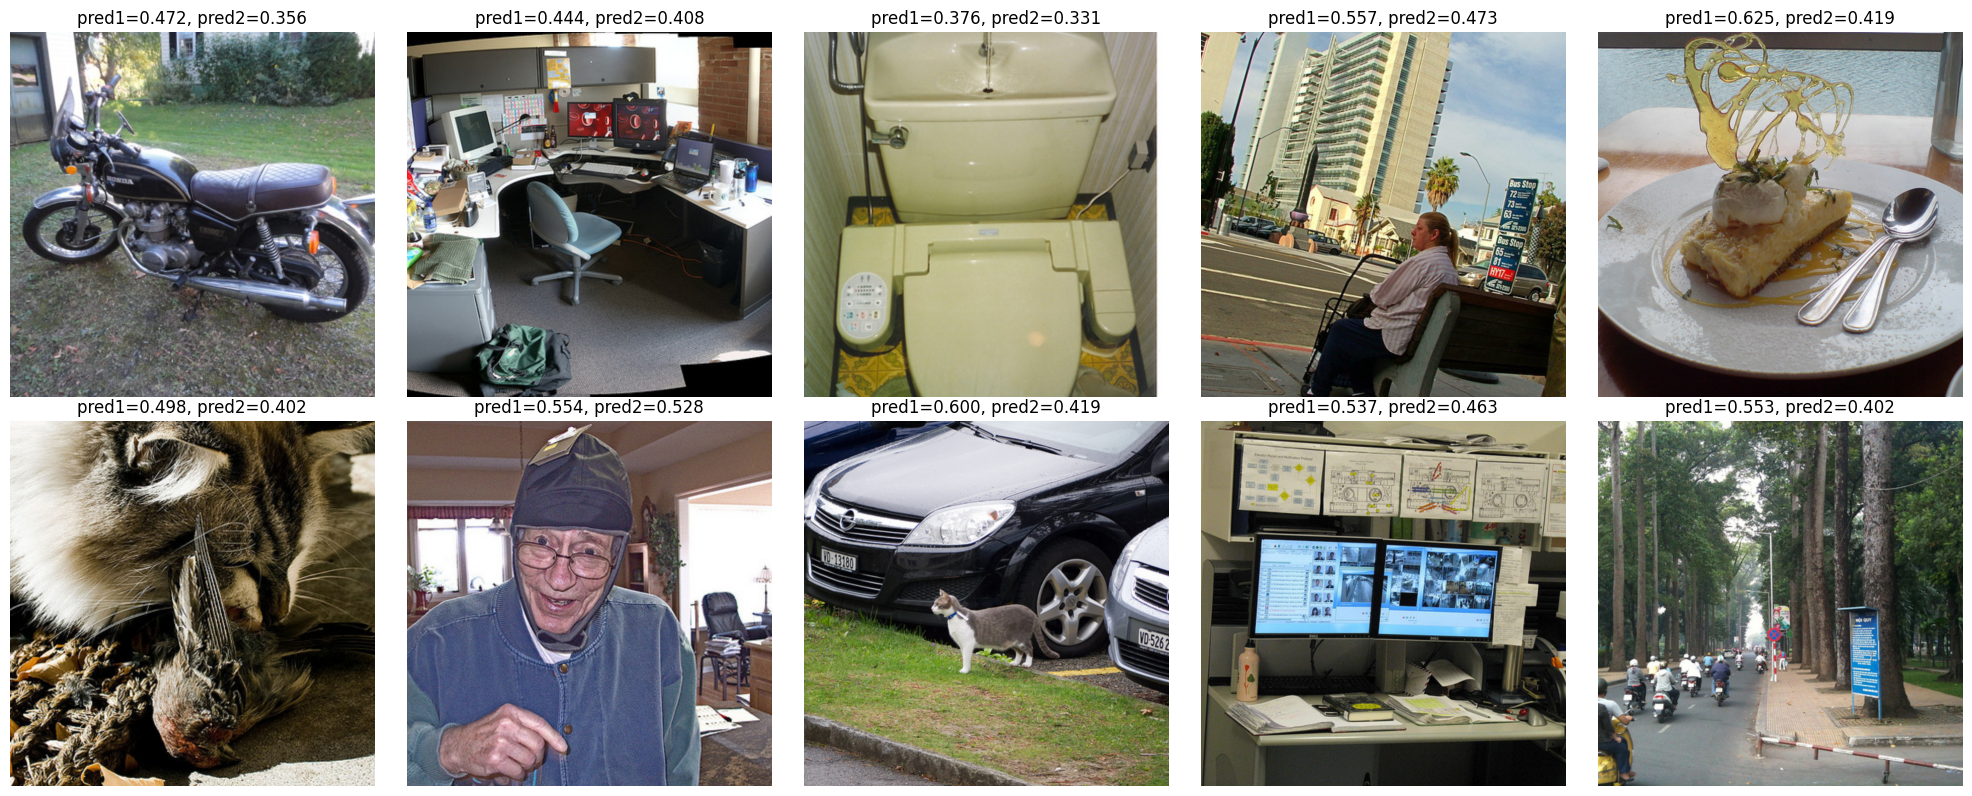

In [15]:
# If your dataset transform includes Normalize(mean=0.5, std=0.5),
# this undoes it for plotting.
def denormalize(img_tensor: torch.Tensor) -> torch.Tensor:
    # img_tensor: (3, H, W)
    img = img_tensor * 0.5 + 0.5
    return img.clamp(0, 1)


model.eval()

imgs_for_plot = []
preds_for_plot = []

for i, (imgs, _) in enumerate(data_loader):
    if i >= 10:
        break

    # predict (move to device inside or here)
    with torch.no_grad():
        preds = predict(imgs)  # shape [1,2] if output_ixs=[0,1]

    imgs_for_plot.append(imgs[0].cpu())        # (3,H,W) on CPU for plotting
    preds_for_plot.append(preds[0].cpu())      # (2,)

# Plot in a grid
n = len(imgs_for_plot)
cols = 5
rows = (n + cols - 1) // cols

plt.figure(figsize=(cols * 4, rows * 4))

for idx in range(n):
    img = imgs_for_plot[idx]
    img = denormalize(img)  # remove this line if your images are already in [0,1]

    v1 = float(preds_for_plot[idx][0])
    v2 = float(preds_for_plot[idx][1])

    ax = plt.subplot(rows, cols, idx + 1)
    ax.imshow(img.permute(1, 2, 0))  # CHW -> HWC
    ax.set_title(f"pred1={v1:.3f}, pred2={v2:.3f}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [16]:
from social_media_overlay.models.regressor import EmotionRegressor

In [17]:
path_to_regressor_model = "../data/gebhardt/models/va_pred_all"
regressor = EmotionRegressor(path_to_regressor_model, device)

In [20]:
predictions = []
for i, (imgs, _) in enumerate(data_loader):
    if i >= 30:
        break

    imgs = imgs.to(device)
    regressor.model.eval()
    preds = regressor.predict(imgs)
    predictions.append(preds.detach().cpu())

predictions = torch.cat(predictions, dim=0)
print(predictions.shape)
print(predictions)

torch.Size([30, 2])
tensor([[0.4840, 0.3551],
        [0.4464, 0.4078],
        [0.3767, 0.3332],
        [0.5589, 0.4743],
        [0.6265, 0.4264],
        [0.5064, 0.4091],
        [0.5458, 0.5254],
        [0.6065, 0.4248],
        [0.5322, 0.4665],
        [0.5505, 0.4004],
        [0.4716, 0.3884],
        [0.4486, 0.3928],
        [0.4943, 0.4065],
        [0.6071, 0.4145],
        [0.5345, 0.6036],
        [0.6494, 0.4148],
        [0.5653, 0.4602],
        [0.6326, 0.4846],
        [0.5418, 0.4667],
        [0.5552, 0.4911],
        [0.3671, 0.4592],
        [0.5092, 0.4214],
        [0.7507, 0.4422],
        [0.6025, 0.3797],
        [0.3519, 0.4364],
        [0.5269, 0.3340],
        [0.6602, 0.3874],
        [0.3767, 0.4234],
        [0.4527, 0.3759],
        [0.4924, 0.4296]])
